# 06 — Synthetic Control Analysis

The **synthetic control method** (Abadie & Gardeazabal, 2003; Abadie et al., 2010)
constructs a weighted combination of donor (control) states that best matches
the treated state's **pre-treatment outcome trajectory**.

Unlike DiD, synthetic control:
- Works well with a single treated unit
- Does not assume parallel trends — instead, it *finds* a data-driven counterfactual
- Provides a transparent, visual test of the counterfactual

### States analysed
- **Louisiana** — expanded January 2016 (late adopter, clean post-2016 window)
- **Virginia** — expanded January 2019 (even later, longer pre-period)

### Outcome: all-cause age-adjusted mortality rate
(highest data completeness across states and years)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import warnings
import os
import sys

warnings.filterwarnings('ignore')
sys.path.insert(0, '..')
from src.plotting import COLORS

os.makedirs('../figures', exist_ok=True)
os.makedirs('../tables', exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})

panel = pd.read_csv('../data/processed/analysis_panel.csv')
panel['state_fips'] = panel['state_fips'].astype(str).str.zfill(2)
print(f'Panel: {panel.shape}')

Panel: (663, 32)


In [2]:
# ── Synthetic control engine ──────────────────────────────────────────────────

def synthetic_control(panel, treated_state, treatment_year, outcome,
                      donor_states=None, predictor_years=None):
    """
    Estimate synthetic control for a single treated state.

    Parameters
    ----------
    panel          : analysis panel DataFrame
    treated_state  : state name (str)
    treatment_year : year expansion took effect
    outcome        : outcome column name
    donor_states   : list of control states (default: never-treated)
    predictor_years: years used to fit weights (default: all pre-treatment)

    Returns
    -------
    dict with keys:
        years, actual, synthetic, weights, gap, rmspe_pre, rmspe_post
    """
    if donor_states is None:
        # Never-treated + states that expanded much later (>= treatment_year + 3)
        donor_states = panel.loc[
            (panel['ever_expanded'] == 0) |
            (panel['cohort_group'] >= treatment_year + 4),
            'state'
        ].unique().tolist()
        # Exclude the treated state itself
        donor_states = [s for s in donor_states if s != treated_state]

    years = sorted(panel['year'].unique())
    pre_years = [y for y in years if y < treatment_year]
    if predictor_years:
        pre_years = [y for y in pre_years if y in predictor_years]

    # Build matrices: rows=years, cols=states
    def get_series(state):
        return (
            panel[panel['state'] == state]
            .set_index('year')[outcome]
            .reindex(years)
        )

    Y_treated = get_series(treated_state).values
    Y_donors  = np.column_stack([get_series(s).values for s in donor_states])

    # Pre-period indices
    pre_idx = [i for i, y in enumerate(years) if y in pre_years]

    # Only use rows where all donors and treated have data
    valid = ~np.isnan(Y_treated[pre_idx])
    for j in range(Y_donors.shape[1]):
        valid &= ~np.isnan(Y_donors[pre_idx, j])
    pre_idx_valid = [pre_idx[i] for i in range(len(pre_idx)) if valid[i]]

    y_pre = Y_treated[pre_idx_valid]
    D_pre = Y_donors[pre_idx_valid, :]
    J     = len(donor_states)

    # Optimise: minimise sum of squared pre-period prediction errors
    def objective(w):
        synth = D_pre @ w
        return np.sum((y_pre - synth) ** 2)

    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds      = [(0, 1)] * J
    w0          = np.ones(J) / J

    result = opt.minimize(objective, w0, method='SLSQP',
                          bounds=bounds, constraints=constraints,
                          options={'ftol': 1e-12, 'maxiter': 2000})
    weights = result.x

    # Synthetic control series over full period
    synth_full = Y_donors @ weights

    gap     = Y_treated - synth_full
    pre_all = np.array([i for i, y in enumerate(years) if y < treatment_year])
    post    = np.array([i for i, y in enumerate(years) if y >= treatment_year])

    def rmspe(idx):
        g = gap[idx]
        return np.sqrt(np.nanmean(g**2))

    top_donors = sorted(
        zip(donor_states, weights), key=lambda x: x[1], reverse=True
    )[:8]

    return {
        'treated_state':  treated_state,
        'treatment_year': treatment_year,
        'years':          np.array(years),
        'actual':         Y_treated,
        'synthetic':      synth_full,
        'gap':            gap,
        'weights':        dict(zip(donor_states, weights)),
        'top_donors':     top_donors,
        'rmspe_pre':      rmspe(pre_all),
        'rmspe_post':     rmspe(post),
        'rmspe_ratio':    rmspe(post) / (rmspe(pre_all) + 1e-10),
    }

print('Synthetic control engine loaded.')

Synthetic control engine loaded.


---
## 1. Louisiana (Expanded 2016)

In [3]:
outcome = 'allcause_age_adj_rate'

sc_la = synthetic_control(
    panel, treated_state='Louisiana', treatment_year=2016, outcome=outcome
)

print(f'Louisiana — All-Cause Age-Adjusted Mortality')
print(f'  Pre-period RMSPE:  {sc_la["rmspe_pre"]:.3f}')
print(f'  Post-period RMSPE: {sc_la["rmspe_post"]:.3f}')
print(f'  RMSPE ratio:       {sc_la["rmspe_ratio"]:.2f}x  '
      f'(>1 = larger post gap than pre)')
print()
print('Top donor weights:')
for state, w in sc_la['top_donors']:
    if w > 0.01:
        print(f'  {state:<25} {w:.3f}')

Louisiana — All-Cause Age-Adjusted Mortality
  Pre-period RMSPE:  10.085
  Post-period RMSPE: 21.426
  RMSPE ratio:       2.12x  (>1 = larger post gap than pre)

Top donor weights:
  Tennessee                 0.628
  Alabama                   0.332
  Texas                     0.040


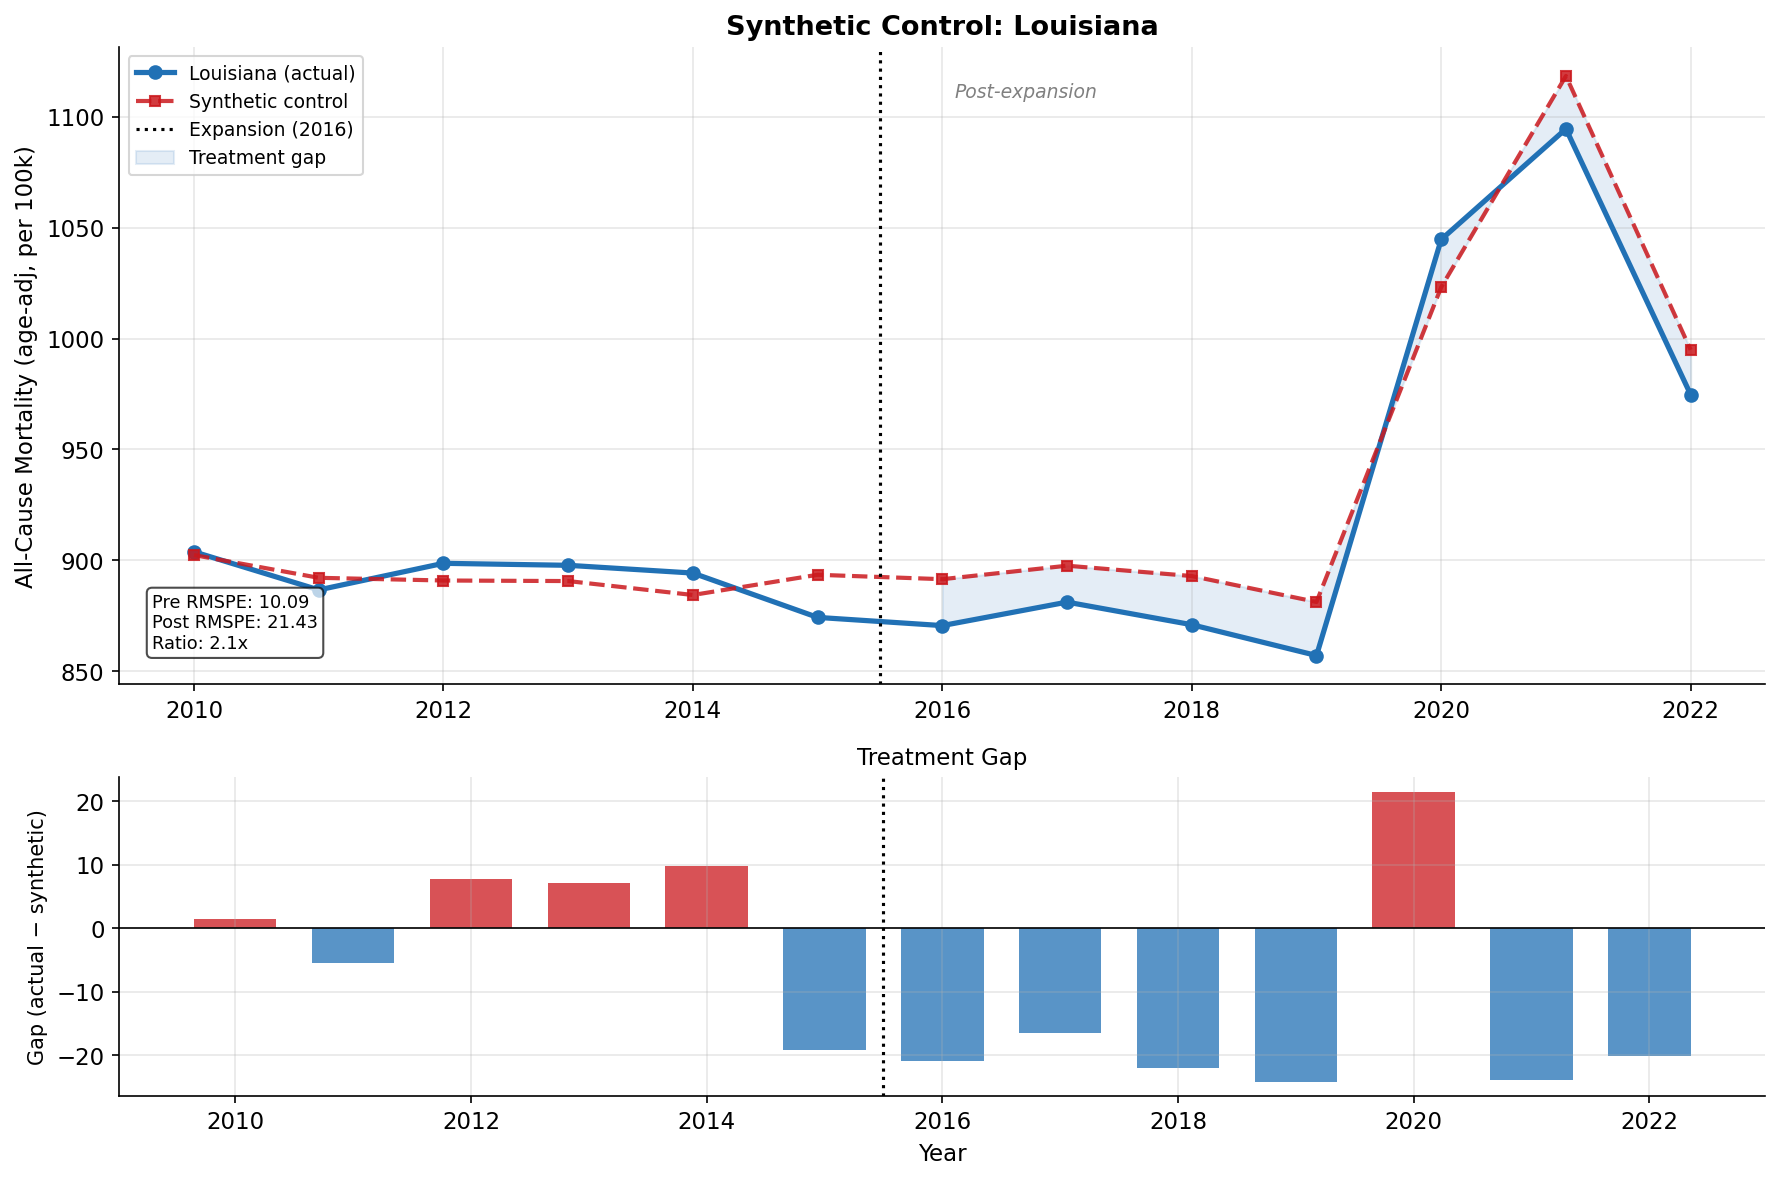

Saved: figures/synthetic_control_louisiana.png


In [4]:
def plot_synthetic_control(sc_result, outcome_label=None, figsize=(12, 8)):
    state   = sc_result['treated_state']
    t_year  = sc_result['treatment_year']
    years   = sc_result['years']
    actual  = sc_result['actual']
    synth   = sc_result['synthetic']
    gap     = sc_result['gap']

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize,
                                    gridspec_kw={'height_ratios': [3, 1.5]})

    # --- Panel A: actual vs synthetic ---
    ax1.plot(years, actual, 'o-', color=COLORS['expansion'],
             linewidth=2.5, markersize=6, label=f'{state} (actual)')
    ax1.plot(years, synth, 's--', color=COLORS['no_expansion'],
             linewidth=2, markersize=5, label='Synthetic control', alpha=0.85)
    ax1.axvline(t_year - 0.5, color='black', linestyle=':', linewidth=1.5,
                label=f'Expansion ({t_year})')
    ax1.fill_between(years, actual, synth,
                     where=(years >= t_year), alpha=0.12,
                     color=COLORS['expansion'], label='Treatment gap')
    ymin, ymax = ax1.get_ylim()
    ax1.text(t_year + 0.1, ymax - (ymax - ymin) * 0.08,
             'Post-expansion', fontsize=9, color='gray', style='italic')
    ax1.set_ylabel(outcome_label or outcome, fontsize=11)
    ax1.set_title(f'Synthetic Control: {state}', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=9)

    rr = sc_result['rmspe_ratio']
    ax1.text(0.02, 0.05,
             f"Pre RMSPE: {sc_result['rmspe_pre']:.2f}\n"
             f"Post RMSPE: {sc_result['rmspe_post']:.2f}\n"
             f"Ratio: {rr:.1f}x",
             transform=ax1.transAxes, fontsize=8.5, va='bottom',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    # --- Panel B: gap ---
    colors_bar = [COLORS['expansion'] if g < 0 else COLORS['no_expansion']
                  for g in gap]
    ax2.bar(years, gap, color=colors_bar, alpha=0.75, width=0.7)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.axvline(t_year - 0.5, color='black', linestyle=':', linewidth=1.5)
    ax2.set_xlabel('Year', fontsize=11)
    ax2.set_ylabel('Gap (actual − synthetic)', fontsize=10)
    ax2.set_title('Treatment Gap', fontsize=11)

    plt.tight_layout()
    return fig

fig_la = plot_synthetic_control(sc_la, outcome_label='All-Cause Mortality (age-adj, per 100k)')
fig_la.savefig('../figures/synthetic_control_louisiana.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/synthetic_control_louisiana.png')

---
## 2. Virginia (Expanded 2019)

Virginia — All-Cause Age-Adjusted Mortality
  Pre-period RMSPE:  70.981
  Post-period RMSPE: 101.609
  RMSPE ratio:       1.43x

Top donor weights:
  Alabama                   0.083
  Florida                   0.083
  Georgia                   0.083
  Kansas                    0.083
  Mississippi               0.083
  North Carolina            0.083
  South Carolina            0.083
  South Dakota              0.083


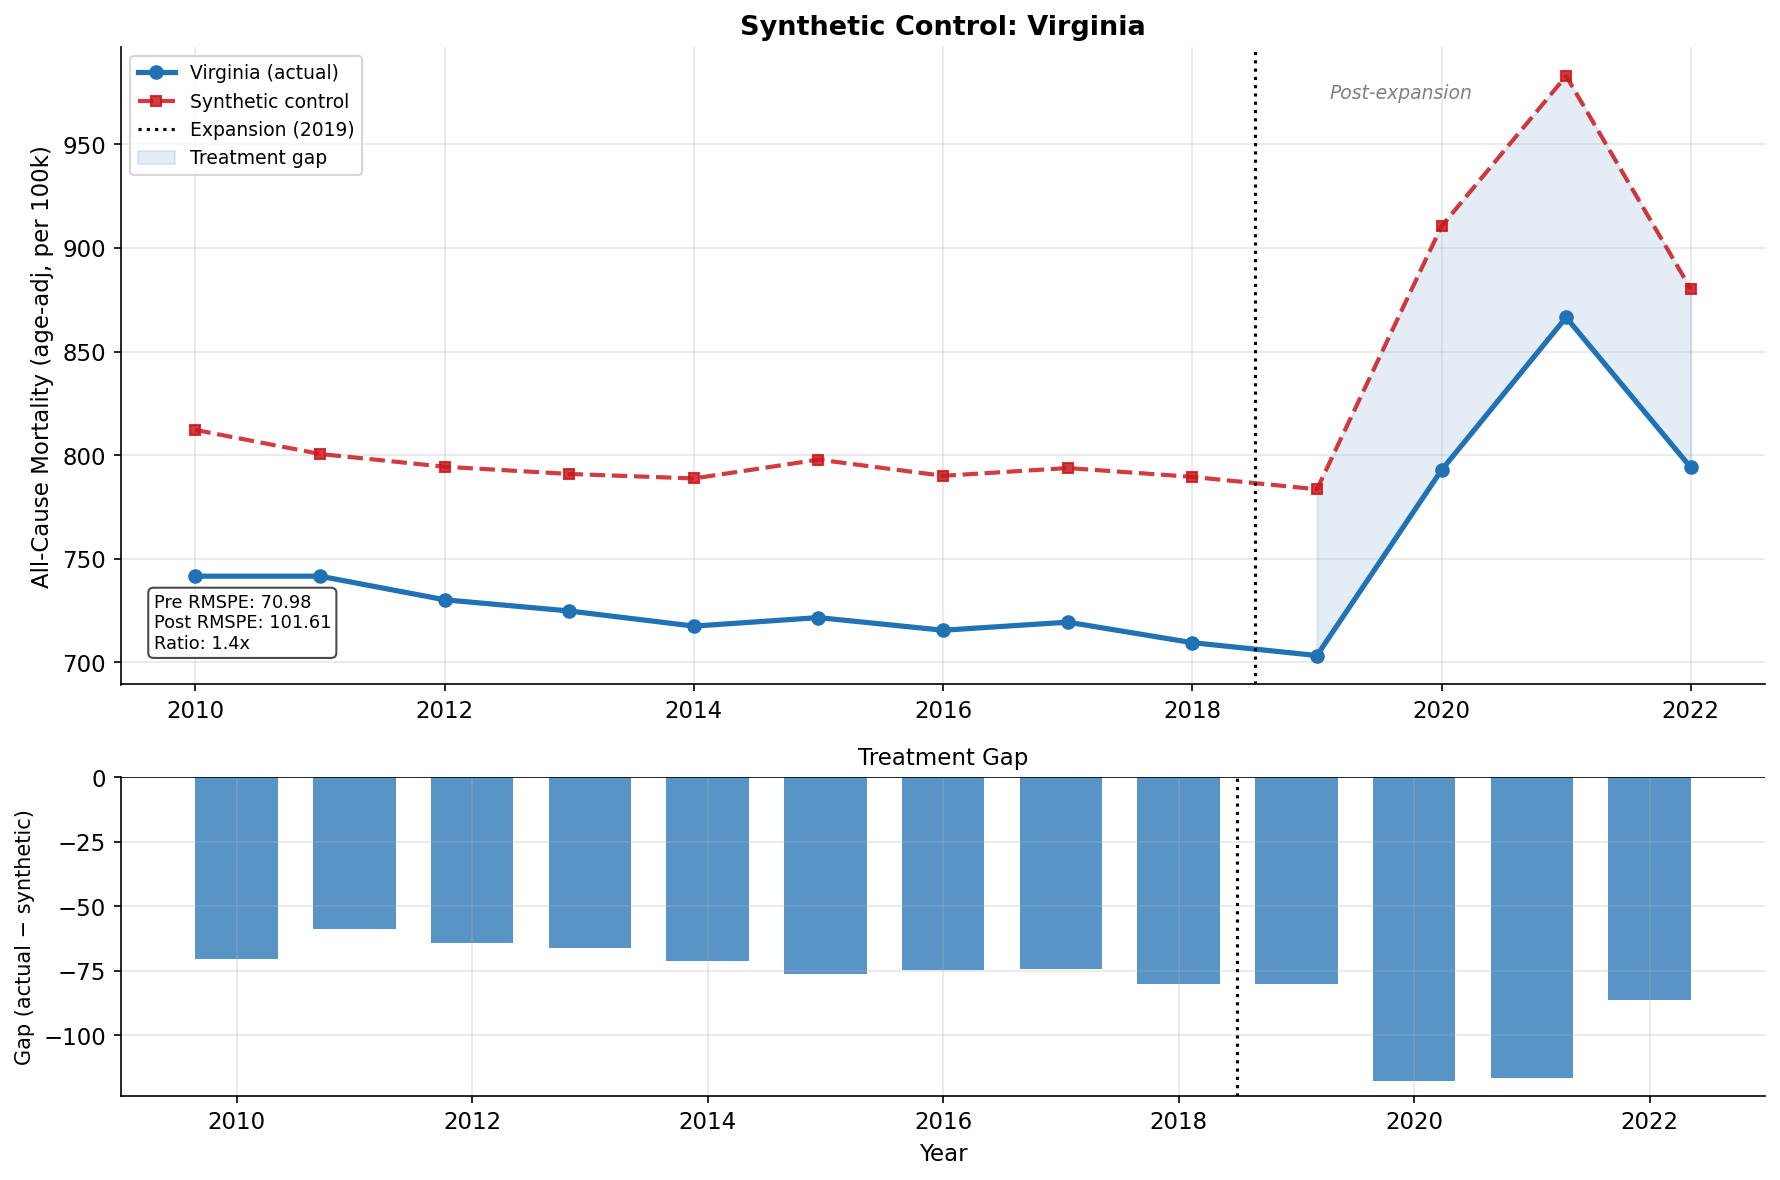

Saved: figures/synthetic_control_virginia.png


In [5]:
sc_va = synthetic_control(
    panel, treated_state='Virginia', treatment_year=2019, outcome=outcome
)

print(f'Virginia — All-Cause Age-Adjusted Mortality')
print(f'  Pre-period RMSPE:  {sc_va["rmspe_pre"]:.3f}')
print(f'  Post-period RMSPE: {sc_va["rmspe_post"]:.3f}')
print(f'  RMSPE ratio:       {sc_va["rmspe_ratio"]:.2f}x')
print()
print('Top donor weights:')
for state, w in sc_va['top_donors']:
    if w > 0.01:
        print(f'  {state:<25} {w:.3f}')

fig_va = plot_synthetic_control(sc_va, outcome_label='All-Cause Mortality (age-adj, per 100k)')
fig_va.savefig('../figures/synthetic_control_virginia.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/synthetic_control_virginia.png')

---
## 3. Placebo Tests (In-Space)

Apply synthetic control to each **donor state** as if it were treated.
If the gap for the actual treated state is large relative to placebo gaps,
it provides evidence of a real treatment effect.

In [6]:
def run_placebo_tests(panel, treated_state, treatment_year, outcome,
                      max_pre_rmspe_ratio=5):
    """
    Run in-space placebo: apply synthetic control to each donor state.
    Exclude placebos with poor pre-period fit (rmspe_pre > ratio * treated_rmspe_pre).
    """
    # Actual result
    actual_sc = synthetic_control(panel, treated_state, treatment_year, outcome)
    rmspe_threshold = actual_sc['rmspe_pre'] * max_pre_rmspe_ratio

    never_treated = panel[
        panel['ever_expanded'] == 0
    ]['state'].unique().tolist()

    placebo_gaps = {}
    print(f'Running placebo for {len(never_treated)} donor states...')
    for donor in never_treated:
        try:
            sc = synthetic_control(
                panel, treated_state=donor,
                treatment_year=treatment_year, outcome=outcome
            )
            if sc['rmspe_pre'] <= rmspe_threshold:
                placebo_gaps[donor] = sc['gap']
        except Exception:
            pass

    print(f'Placebos retained (good pre-fit): {len(placebo_gaps)}')
    return actual_sc, placebo_gaps

sc_la_actual, la_placebos = run_placebo_tests(
    panel, 'Louisiana', 2016, outcome
)

Running placebo for 10 donor states...


Placebos retained (good pre-fit): 8


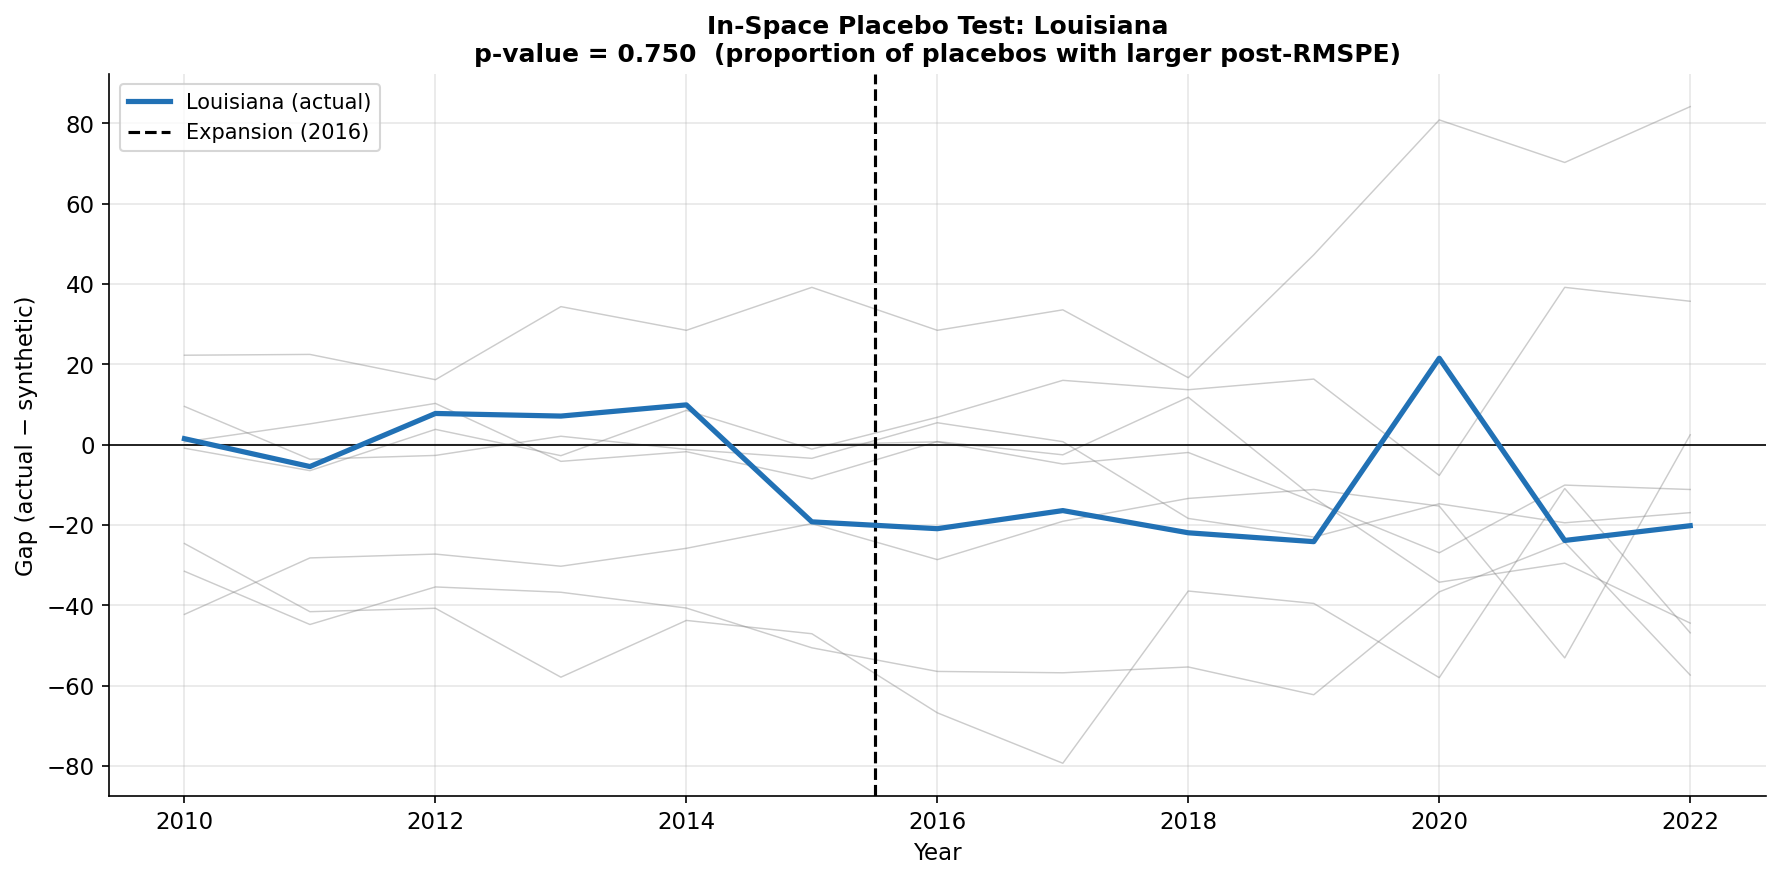

Louisiana placebo p-value: 0.750
Saved: figures/synthetic_control_louisiana_placebo.png


In [7]:
def plot_placebo_gaps(actual_sc, placebo_gaps, figsize=(12, 6)):
    years      = actual_sc['years']
    actual_gap = actual_sc['gap']
    t_year     = actual_sc['treatment_year']
    state      = actual_sc['treated_state']

    fig, ax = plt.subplots(figsize=figsize)

    for donor, gap in placebo_gaps.items():
        ax.plot(years, gap, color='gray', linewidth=0.7, alpha=0.4)

    ax.plot(years, actual_gap, color=COLORS['expansion'],
            linewidth=2.5, zorder=5, label=f'{state} (actual)')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(t_year - 0.5, color='black', linestyle='--',
               linewidth=1.5, label=f'Expansion ({t_year})')

    # P-value annotation
    post_idx  = years >= t_year
    actual_post_rmspe = np.sqrt(np.nanmean(actual_gap[post_idx]**2))
    placebo_post_rmspe = [
        np.sqrt(np.nanmean(g[post_idx]**2))
        for g in placebo_gaps.values()
        if not np.all(np.isnan(g[post_idx]))
    ]
    p_val = np.mean(
        [r >= actual_post_rmspe for r in placebo_post_rmspe]
    ) if placebo_post_rmspe else np.nan

    ax.set_title(
        f'In-Space Placebo Test: {state}\n'
        f'p-value = {p_val:.3f}  (proportion of placebos with larger post-RMSPE)',
        fontsize=12, fontweight='bold'
    )
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Gap (actual − synthetic)', fontsize=11)
    ax.legend(fontsize=10)
    plt.tight_layout()
    return fig, p_val

fig_pl, la_pval = plot_placebo_gaps(sc_la_actual, la_placebos)
fig_pl.savefig('../figures/synthetic_control_louisiana_placebo.png',
               dpi=150, bbox_inches='tight')
plt.show()
print(f'Louisiana placebo p-value: {la_pval:.3f}')
print('Saved: figures/synthetic_control_louisiana_placebo.png')

---
## 4. Summary Table

In [8]:
# Average post-expansion gap
rows = []
for sc in [sc_la_actual, sc_va]:
    post = sc['years'] >= sc['treatment_year']
    avg_gap = np.nanmean(sc['gap'][post])
    rows.append({
        'state':          sc['treated_state'],
        'treatment_year': sc['treatment_year'],
        'avg_post_gap':   round(avg_gap, 3),
        'rmspe_pre':      round(sc['rmspe_pre'], 3),
        'rmspe_post':     round(sc['rmspe_post'], 3),
        'rmspe_ratio':    round(sc['rmspe_ratio'], 2),
    })

sc_summary = pd.DataFrame(rows)
display(sc_summary)
sc_summary.to_csv('../tables/synthetic_control_results.csv', index=False)
print('Saved: tables/synthetic_control_results.csv')
print()
print('Interpretation:')
print('  avg_post_gap < 0  => actual mortality BELOW synthetic (expansion reduced mortality)')
print('  rmspe_ratio > 1   => post-treatment fit is worse than pre  (treatment effect present)')

,state,treatment_year,avg_post_gap,rmspe_pre,rmspe_post,rmspe_ratio
0,Louisiana,2016,-15.147,10.085,21.426,2.12
1,Virginia,2019,-100.160,70.981,101.609,1.43


Saved: tables/synthetic_control_results.csv

Interpretation:
  avg_post_gap < 0  => actual mortality BELOW synthetic (expansion reduced mortality)
  rmspe_ratio > 1   => post-treatment fit is worse than pre  (treatment effect present)
